In [4]:
# %% [markdown]
# # Data Exploration for Time Series Clustering
# ## Team [6] - RDKD 2026 Project
# 
# This notebook explores the energy consumption data for 2023 before clustering.

# %% [markdown]
# ## 1. Setup and Imports

# %%
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Add project root to path
project_root = Path.cwd().parent
sys.path.append(str(project_root))

# Import our modules
from src.config import (
    PROCESSED_DATA_DIR, FIGURES_DIR, 
    RANDOM_SEED, ZERO_THRESHOLD, CONSTANT_THRESHOLD
)
from src.data_loader import load_data, quick_check
from src.preprocessing import (
    identify_problematic_series, 
    impute_missing_values, 
    normalize_series,
    plot_preprocessing_comparison
)

# Set random seed
np.random.seed(RANDOM_SEED)


✅ Project root set to: /Users/fahad/Documents/MY#Documents/FAHAD ALI/Uni Wien/6th Semester/RDKD/ProjectWORK
✅ Created/Verified: /Users/fahad/Documents/MY#Documents/FAHAD ALI/Uni Wien/6th Semester/RDKD/ProjectWORK/data/raw
✅ Created/Verified: /Users/fahad/Documents/MY#Documents/FAHAD ALI/Uni Wien/6th Semester/RDKD/ProjectWORK/data/processed
✅ Created/Verified: /Users/fahad/Documents/MY#Documents/FAHAD ALI/Uni Wien/6th Semester/RDKD/ProjectWORK/outputs/clustering
✅ Created/Verified: /Users/fahad/Documents/MY#Documents/FAHAD ALI/Uni Wien/6th Semester/RDKD/ProjectWORK/outputs/forecasting
✅ Created/Verified: /Users/fahad/Documents/MY#Documents/FAHAD ALI/Uni Wien/6th Semester/RDKD/ProjectWORK/outputs/evaluation
✅ Created/Verified: /Users/fahad/Documents/MY#Documents/FAHAD ALI/Uni Wien/6th Semester/RDKD/ProjectWORK/outputs/figures

✅ Configuration loaded successfully!
📁 Data will be read from: /Users/fahad/Documents/MY#Documents/FAHAD ALI/Uni Wien/6th Semester/RDKD/ProjectWORK/data/raw
📁 Outp

In [5]:
# ## 2. Load the Data
# Load data

df_2023, df_2024 = load_data()

# Quick check
info = quick_check(df_2023, df_2024)
print("\n📊 Data Summary:")
for key, value in info.items():
    print(f"   {key}: {value}")


LOADING DATA

✅ Loaded 2023 data:
   - Shape: (17547, 366)
   - Number of households: 17547
   - Number of days (2023): 365

✅ Loaded 2024 data:
   - Shape: (17547, 367)
   - Number of households: 17547
   - Number of days (2024 leap year): 366

📊 Data Summary:
   n_households_2023: 17547
   n_days_2023: 365
   n_households_2024: 17547
   n_days_2024: 366
   missing_2023: 0
   missing_2024: 0
   ids_match: True


In [6]:
# ## 3. Basic Statistics
# Get all consumption values (flatten the dataframe, exclude ID)

all_values = df_2023.iloc[:, 1:].values.flatten()

print("="*60)
print("OVERALL STATISTICS (2023)")
print("="*60)
print(f"Mean: {np.mean(all_values):.2f}")
print(f"Std: {np.std(all_values):.2f}")
print(f"Min: {np.min(all_values):.2f}")
print(f"25th percentile: {np.percentile(all_values, 25):.2f}")
print(f"Median: {np.median(all_values):.2f}")
print(f"75th percentile: {np.percentile(all_values, 75):.2f}")
print(f"Max: {np.max(all_values):.2f}")

# Check for anomalies
print("\n⚠️ ANOMALY CHECK:")
print(f"Zero values: {(all_values == 0).sum()} ({(all_values == 0).sum()/len(all_values)*100:.2f}%)")
print(f"Negative values: {(all_values < 0).sum()} ({(all_values < 0).sum()/len(all_values)*100:.2f}%)")


OVERALL STATISTICS (2023)
Mean: 9.13
Std: 11.90
Min: 0.00
25th percentile: 3.04
Median: 6.05
75th percentile: 10.86
Max: 1051.74

⚠️ ANOMALY CHECK:
Zero values: 168566 (2.63%)
Negative values: 0 (0.00%)


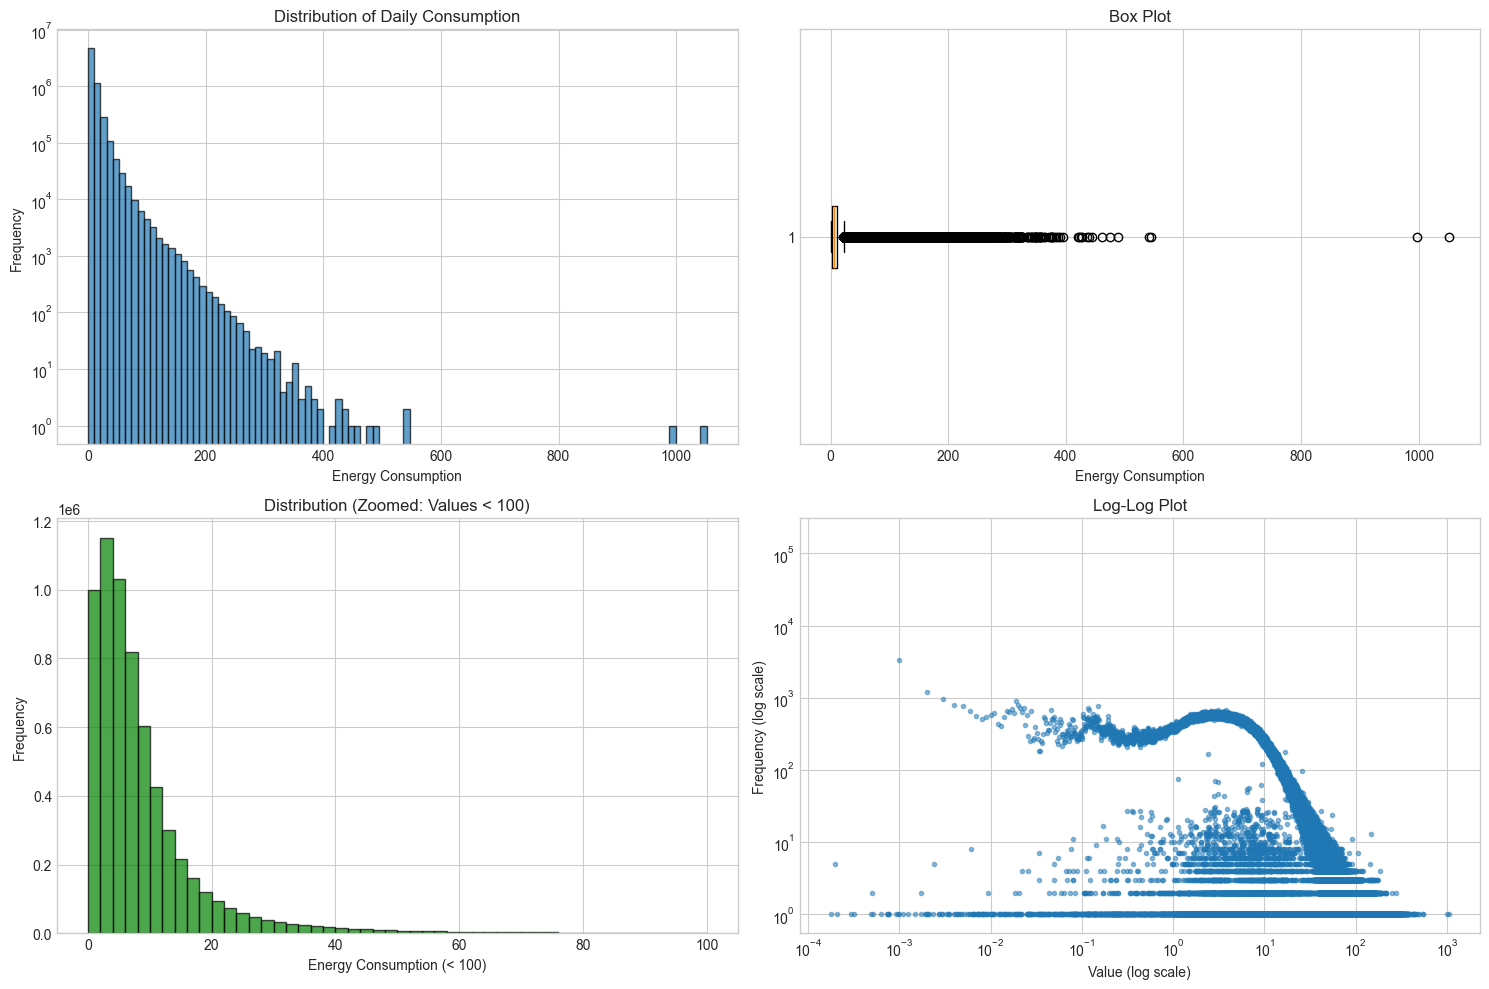

In [7]:
# ## 4. Distribution Visualization
# Create a figure with multiple plots

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Histogram
axes[0, 0].hist(all_values, bins=100, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Energy Consumption')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Daily Consumption')
axes[0, 0].set_yscale('log')

# Box plot
axes[0, 1].boxplot(all_values, vert=False)
axes[0, 1].set_xlabel('Energy Consumption')
axes[0, 1].set_title('Box Plot')

# Zoomed histogram (values < 100)
values_under_100 = all_values[all_values < 100]
axes[1, 0].hist(values_under_100, bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1, 0].set_xlabel('Energy Consumption (< 100)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution (Zoomed: Values < 100)')

# Log-log plot to see power law behavior
from collections import Counter
value_counts = Counter(all_values)
x = sorted(value_counts.keys())
y = [value_counts[v] for v in x]
axes[1, 1].loglog(x, y, '.', alpha=0.5)
axes[1, 1].set_xlabel('Value (log scale)')
axes[1, 1].set_ylabel('Frequency (log scale)')
axes[1, 1].set_title('Log-Log Plot')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'distribution_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

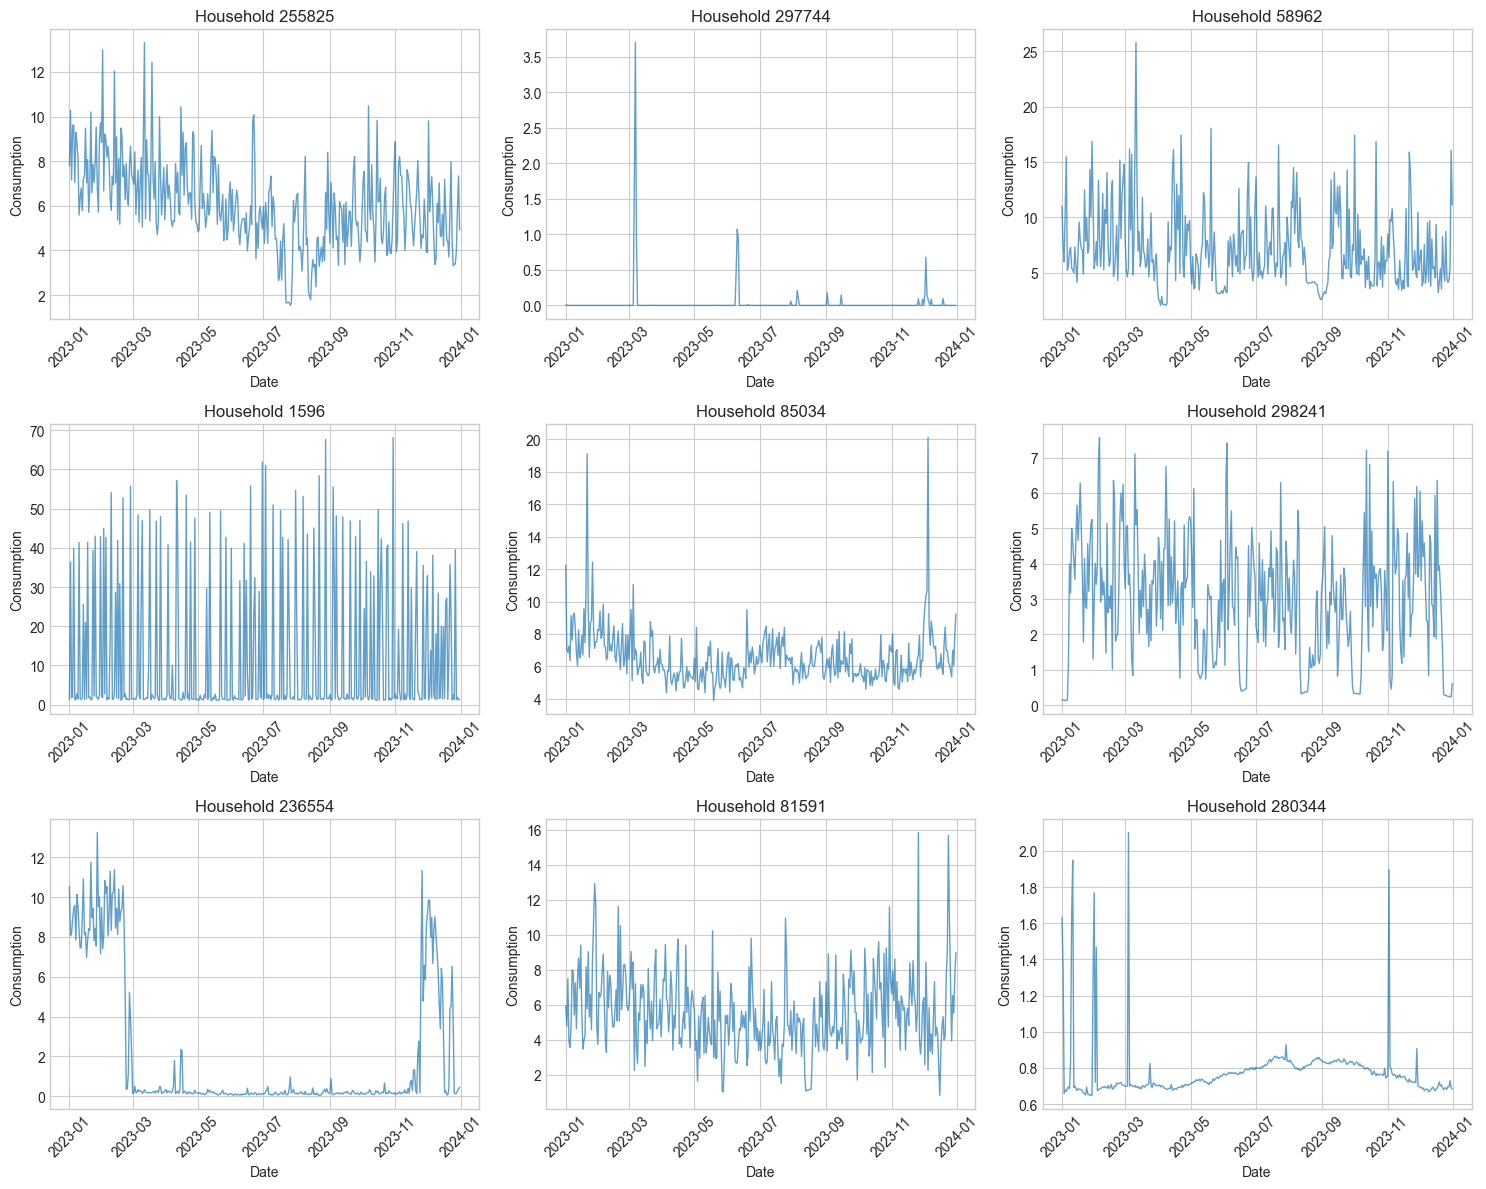

In [8]:
# ## 5. Sample Time Series Visualization
# Plot 9 random households

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

# Select random households
sample_ids = np.random.choice(df_2023['ID'], size=9, replace=False)
dates = pd.date_range(start='2023-01-01', periods=365, freq='D')

for i, household_id in enumerate(sample_ids):
    # Get the time series
    series = df_2023[df_2023['ID'] == household_id].iloc[:, 1:].values.flatten()
    
    axes[i].plot(dates, series, linewidth=1, alpha=0.7)
    axes[i].set_title(f'Household {int(household_id)}')
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Consumption')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'sample_households.png', dpi=150, bbox_inches='tight')
plt.show()




IDENTIFYING PROBLEMATIC SERIES

📊 Problematic series summary:
   - All zeros: 154 households
   - Mostly zeros (>=30.0% zeros): 432 households
   - Constant/near constant: 24 households
   - Negative values: 0 households
   - TOTAL problematic: 610 households

 Total problematic households: 610 out of 17547 (3.5%)


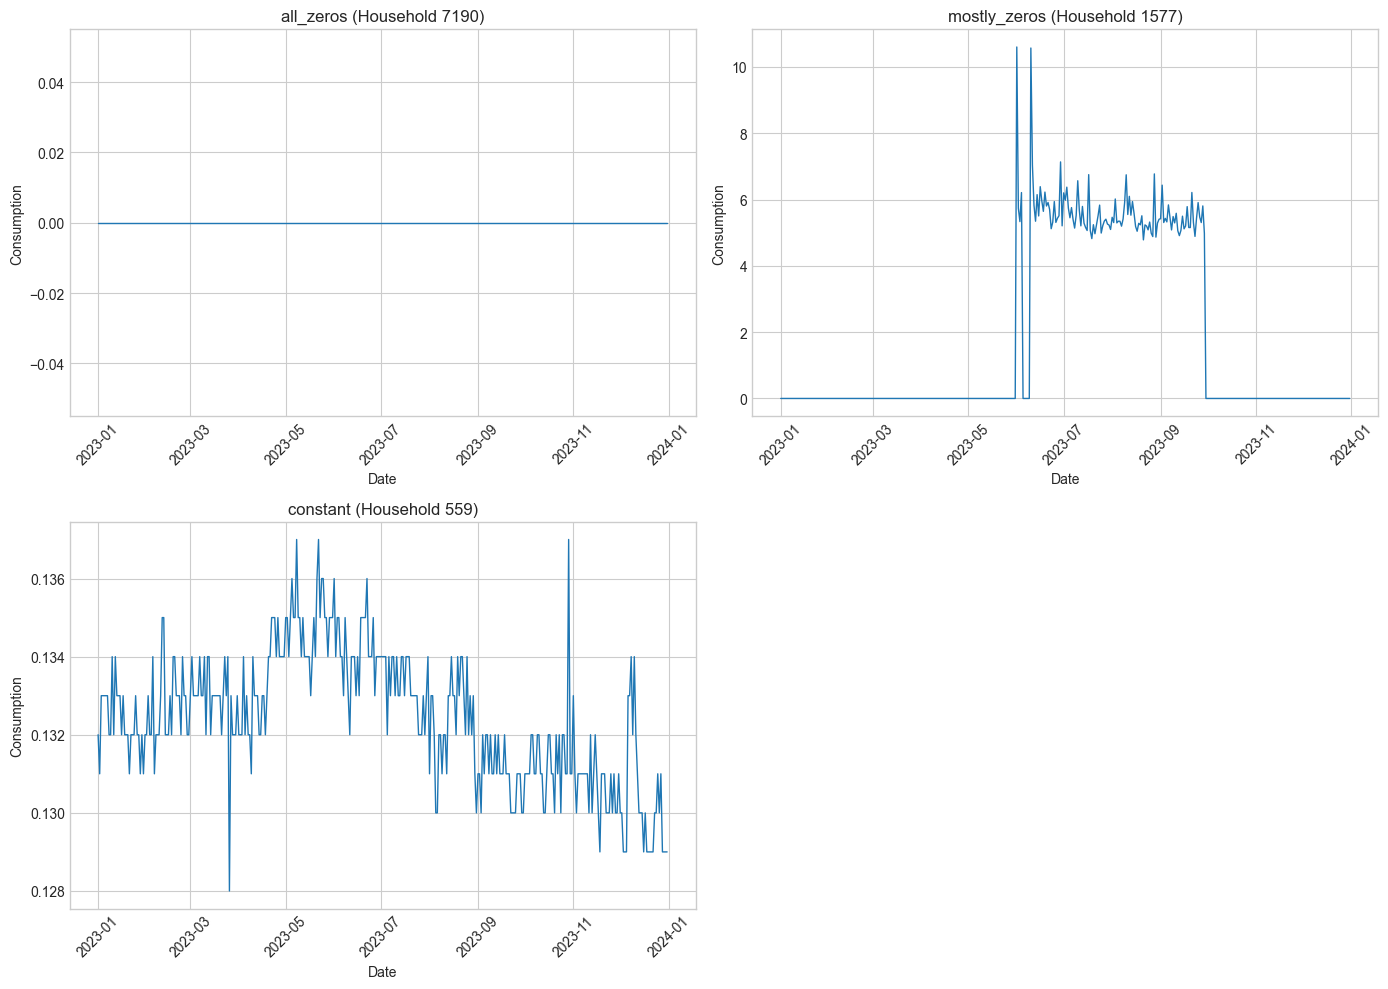

In [9]:
# ## 6. Identify Problematic Series
# Find problematic series (all zeros, constant, etc.)

problematic_ids, problem_report = identify_problematic_series(
    df_2023, 
    zero_threshold=ZERO_THRESHOLD,
    constant_threshold=CONSTANT_THRESHOLD
)

print(f"\n Total problematic households: {len(problematic_ids)} out of {len(df_2023)} ({len(problematic_ids)/len(df_2023)*100:.1f}%)")

# Plot examples of each problem type
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

plot_idx = 0
for problem_type, ids in problem_report.items():
    if ids and plot_idx < 4:  # Plot first 4 problem types
        household_id = ids[0]  # Take first example
        series = df_2023[df_2023['ID'] == household_id].iloc[:, 1:].values.flatten()
        
        axes[plot_idx].plot(dates, series, linewidth=1)
        axes[plot_idx].set_title(f'{problem_type} (Household {int(household_id)})')
        axes[plot_idx].set_xlabel('Date')
        axes[plot_idx].set_ylabel('Consumption')
        axes[plot_idx].tick_params(axis='x', rotation=45)
        plot_idx += 1

# Hide unused subplots
for j in range(plot_idx, 4):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'problematic_series.png', dpi=150, bbox_inches='tight')
plt.show()


Reshaping data for seasonal analysis...
Long format shape: (365000, 6)


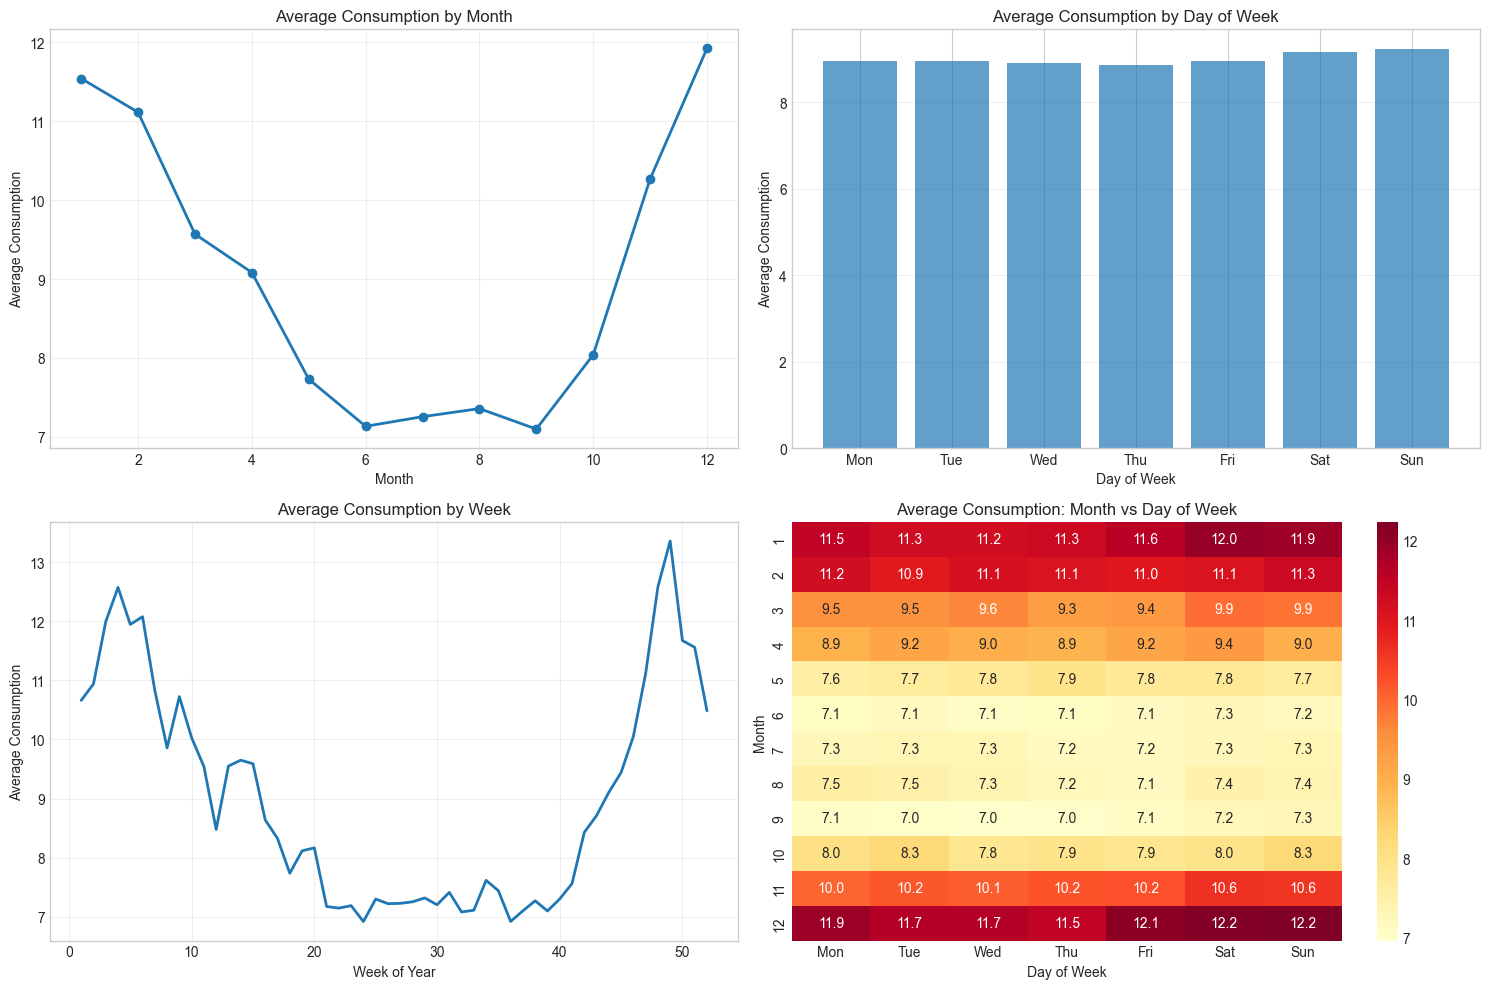

In [11]:
# ## 7. Seasonal Pattern Analysis
# Calculate average consumption per day of week and month
# First, reshape data to long format
print("Reshaping data for seasonal analysis...")

# Take a sample of 1000 households for faster computation
sample_households = np.random.choice(df_2023['ID'], size=1000, replace=False)
df_sample = df_2023[df_2023['ID'].isin(sample_households)]

# Melt to long format
df_long = pd.melt(
    df_sample, 
    id_vars=['ID'], 
    var_name='date', 
    value_name='consumption'
)
df_long['date'] = pd.to_datetime(df_long['date'])
df_long['month'] = df_long['date'].dt.month
df_long['day_of_week'] = df_long['date'].dt.dayofweek  # Monday=0, Sunday=6
df_long['week'] = df_long['date'].dt.isocalendar().week

print(f"Long format shape: {df_long.shape}")

# %%
# Plot seasonal patterns
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# By month
monthly_avg = df_long.groupby('month')['consumption'].mean()
axes[0, 0].plot(monthly_avg.index, monthly_avg.values, 'o-', linewidth=2)
axes[0, 0].set_xlabel('Month')
axes[0, 0].set_ylabel('Average Consumption')
axes[0, 0].set_title('Average Consumption by Month')
axes[0, 0].grid(True, alpha=0.3)

# By day of week
dow_avg = df_long.groupby('day_of_week')['consumption'].mean()
dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[0, 1].bar(dow_labels, dow_avg.values, alpha=0.7)
axes[0, 1].set_xlabel('Day of Week')
axes[0, 1].set_ylabel('Average Consumption')
axes[0, 1].set_title('Average Consumption by Day of Week')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# By week of year
weekly_avg = df_long.groupby('week')['consumption'].mean()
axes[1, 0].plot(weekly_avg.index, weekly_avg.values, linewidth=2)
axes[1, 0].set_xlabel('Week of Year')
axes[1, 0].set_ylabel('Average Consumption')
axes[1, 0].set_title('Average Consumption by Week')
axes[1, 0].grid(True, alpha=0.3)

# Heatmap of month vs day of week
pivot_table = df_long.pivot_table(
    values='consumption', 
    index='month', 
    columns='day_of_week',
    aggfunc='mean'
)
sns.heatmap(pivot_table, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[1, 1])
axes[1, 1].set_xlabel('Day of Week')
axes[1, 1].set_ylabel('Month')
axes[1, 1].set_title('Average Consumption: Month vs Day of Week')
axes[1, 1].set_xticklabels(dow_labels)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'seasonal_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

Calculating per-household statistics...
                  ID          mean           std            cv           min  \
count   17547.000000  17547.000000  17547.000000  17393.000000  17547.000000   
mean   153265.984898      9.131048      4.506049      0.555006      2.624746   
std     88233.186987      9.405481      5.728846      0.772551      3.662224   
min        22.000000      0.000000      0.000000      0.005393      0.000000   
25%     77002.500000      3.869212      1.568962      0.309053      0.806000   
50%    153934.000000      6.776293      2.615201      0.408920      1.737000   
75%    230109.000000     11.356133      4.894331      0.584268      3.338500   
max    304933.000000    188.015227     91.856554     19.078784     88.363000   

                max         range      zero_pct  
count  17547.000000  17547.000000  17547.000000  
mean      27.153188     24.528442      2.631929  
std       31.580474     30.278682     13.591494  
min        0.000000      0.000000      

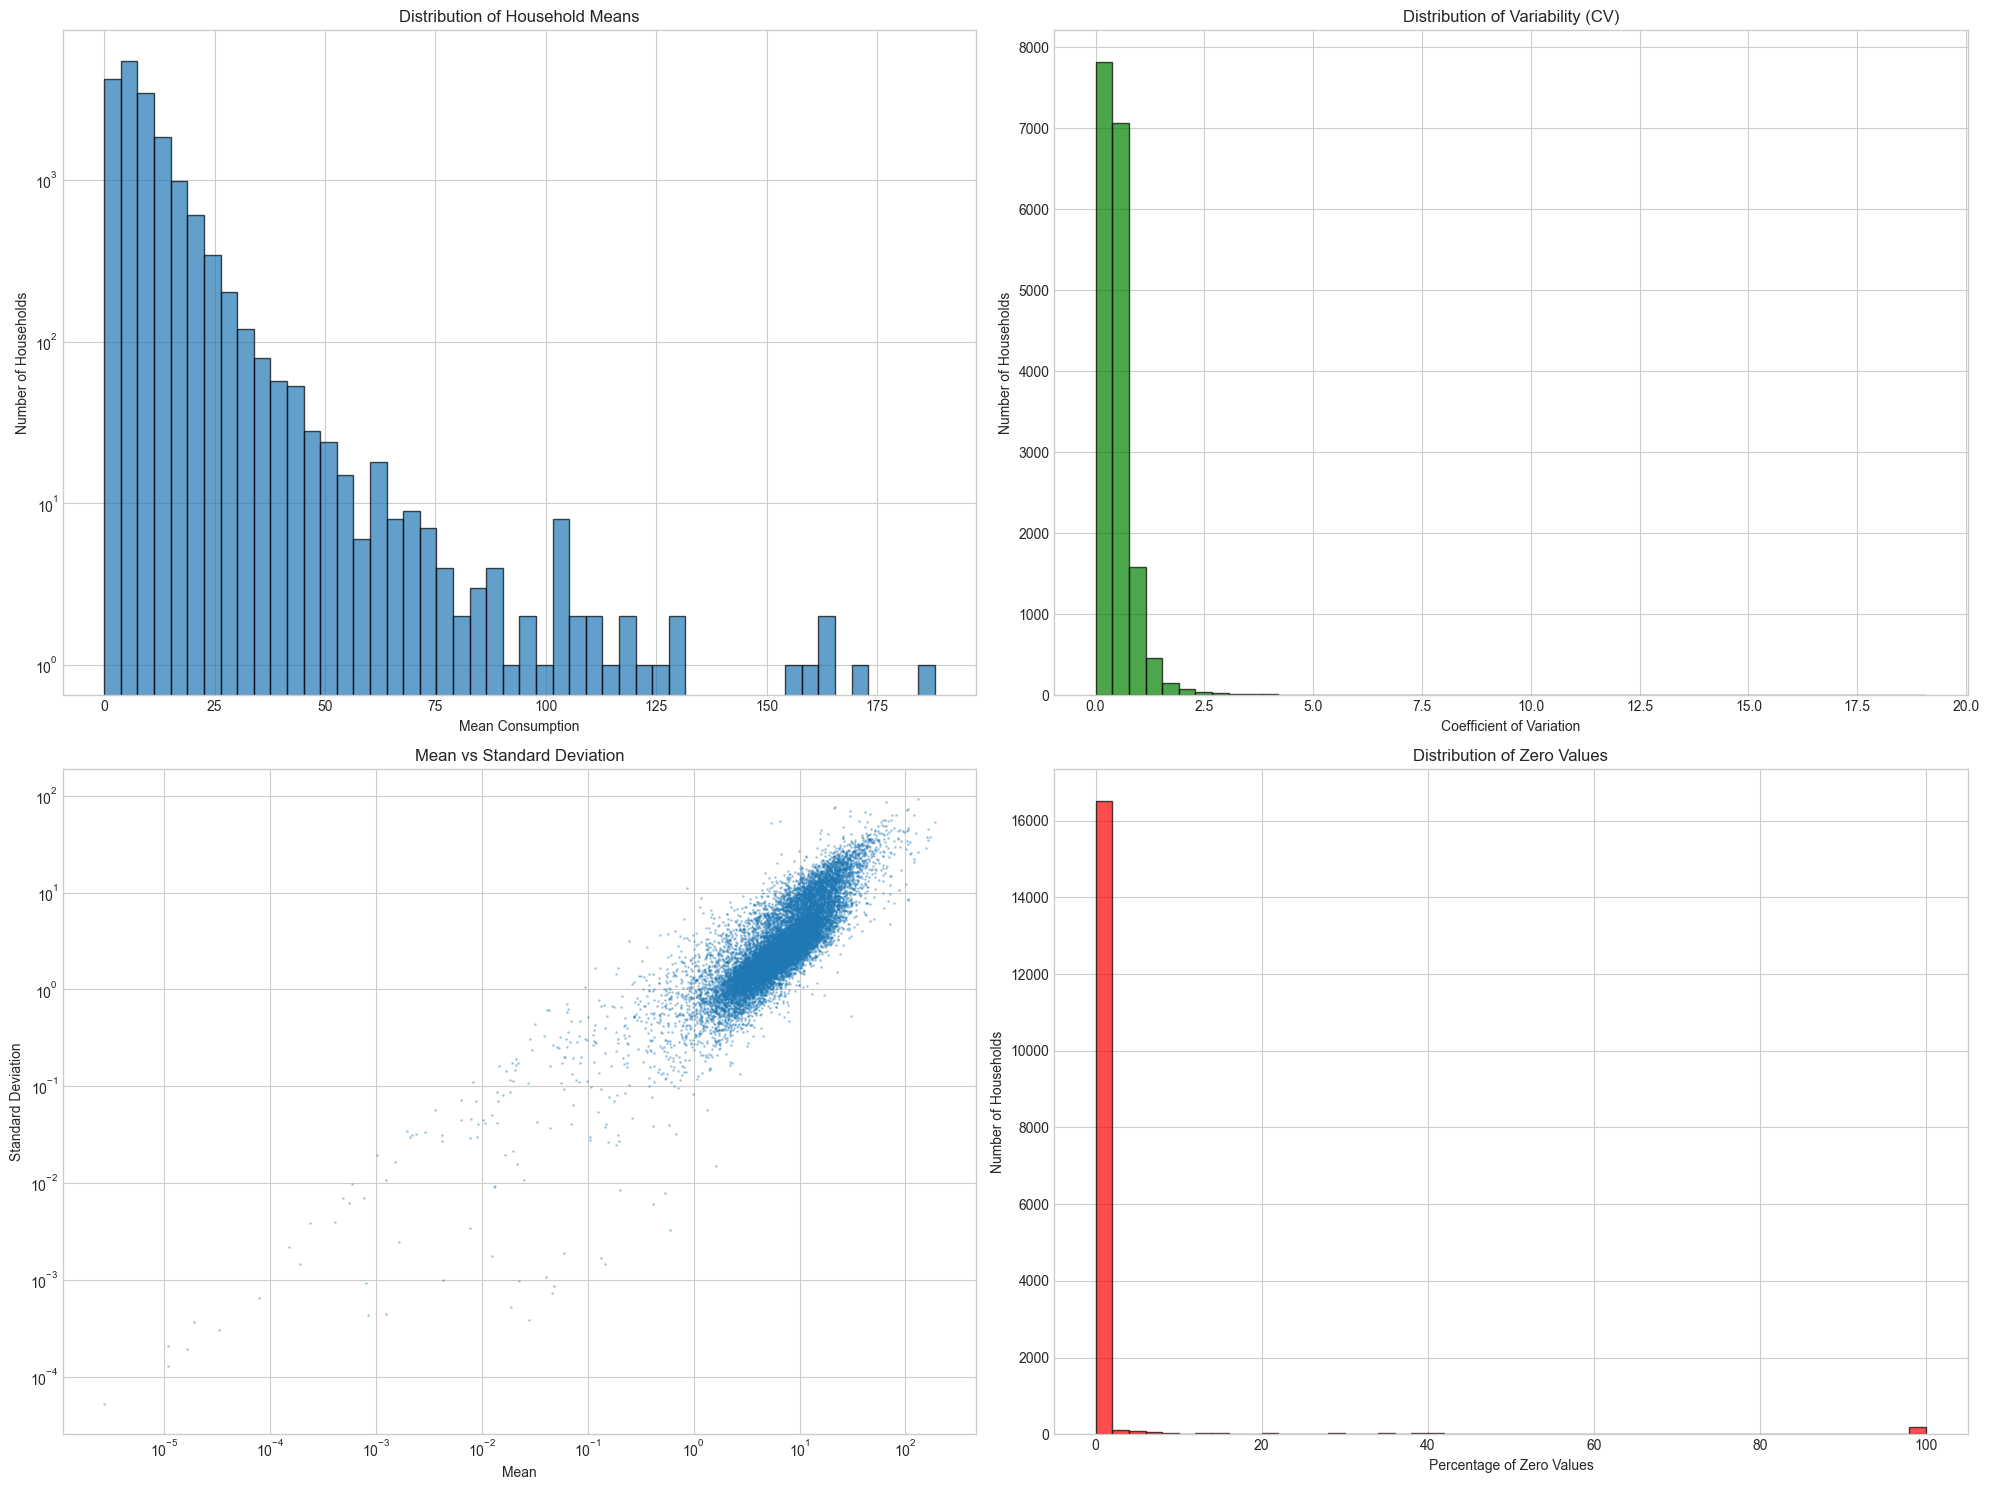

In [13]:
# ## 8. Household Variability Analysis
# Calculate statistics per household

print("Calculating per-household statistics...")

household_stats = []
for idx in df_2023.index:
    household_id = df_2023.loc[idx, 'ID']
    series = df_2023.loc[idx, df_2023.columns[1:]].values
    
    stats = {
        'ID': household_id,
        'mean': np.mean(series),
        'std': np.std(series),
        'cv': np.std(series) / np.mean(series) if np.mean(series) > 0 else np.nan,  # coefficient of variation
        'min': np.min(series),
        'max': np.max(series),
        'range': np.max(series) - np.min(series),
        'zero_pct': (series == 0).sum() / len(series) * 100
    }
    household_stats.append(stats)

df_stats = pd.DataFrame(household_stats)
print(df_stats.describe())

# Plot household statistics
fig, axes = plt.subplots(2, 2, figsize=(20, 15))

# Distribution of means
axes[0, 0].hist(df_stats['mean'].dropna(), bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Mean Consumption')
axes[0, 0].set_ylabel('Number of Households')
axes[0, 0].set_title('Distribution of Household Means')
axes[0, 0].set_yscale('log')

# Distribution of CV (coefficient of variation)
axes[0, 1].hist(df_stats['cv'].dropna(), bins=50, edgecolor='black', alpha=0.7, color='green')
axes[0, 1].set_xlabel('Coefficient of Variation')
axes[0, 1].set_ylabel('Number of Households')
axes[0, 1].set_title('Distribution of Variability (CV)')

# Mean vs Std scatter
axes[1, 0].scatter(df_stats['mean'], df_stats['std'], alpha=0.3, s=1)
axes[1, 0].set_xlabel('Mean')
axes[1, 0].set_ylabel('Standard Deviation')
axes[1, 0].set_title('Mean vs Standard Deviation')
axes[1, 0].set_xscale('log')
axes[1, 0].set_yscale('log')

# Zero percentage distribution
axes[1, 1].hist(df_stats['zero_pct'], bins=50, edgecolor='black', alpha=0.7, color='red')
axes[1, 1].set_xlabel('Percentage of Zero Values')
axes[1, 1].set_ylabel('Number of Households')
axes[1, 1].set_title('Distribution of Zero Values')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'household_statistics.png', dpi=150, bbox_inches='tight')
plt.show()


In [14]:
# ## 9. Key Findings and Next Steps

print("="*60)
print("KEY FINDINGS")
print("="*60)

print(f"\n📊 Dataset Overview:")
print(f"   - {info['n_households_2023']} households")
print(f"   - {info['n_days_2023']} days in 2023")
print(f"   - {info['n_days_2024']} days in 2024 (leap year)")

print(f"\n⚠️ Data Quality:")
print(f"   - Missing values: {info['missing_2023']}")
print(f"   - Problematic series: {len(problematic_ids)} ({len(problematic_ids)/info['n_households_2023']*100:.1f}%)")
for problem_type, ids in problem_report.items():
    if ids:
        print(f"     * {problem_type}: {len(ids)}")

print(f"\n📈 Consumption Patterns:")
print(f"   - Overall mean: {np.mean(all_values):.2f}")
print(f"   - Overall median: {np.median(all_values):.2f}")
print(f"   - Household means range: [{df_stats['mean'].min():.2f}, {df_stats['mean'].max():.2f}]")

print(f"\n✅ All figures saved to: {FIGURES_DIR}")



KEY FINDINGS

📊 Dataset Overview:
   - 17547 households
   - 365 days in 2023
   - 366 days in 2024 (leap year)

⚠️ Data Quality:
   - Missing values: 0
   - Problematic series: 610 (3.5%)
     * all_zeros: 154
     * mostly_zeros: 432
     * constant: 24

📈 Consumption Patterns:
   - Overall mean: 9.13
   - Overall median: 6.05
   - Household means range: [0.00, 188.02]

✅ All figures saved to: /Users/fahad/Documents/MY#Documents/FAHAD ALI/Uni Wien/6th Semester/RDKD/ProjectWORK/outputs/figures


In [15]:
# ## 10. Save Processed Data
# Save household statistics for later use

df_stats.to_csv(PROCESSED_DATA_DIR / 'household_statistics.csv', index=False)
print(f"✅ Saved household statistics to {PROCESSED_DATA_DIR / 'household_statistics.csv'}")

# Save problematic IDs
pd.DataFrame({'problematic_ids': problematic_ids}).to_csv(
    PROCESSED_DATA_DIR / 'problematic_ids.csv', index=False
)
print(f"✅ Saved problematic IDs to {PROCESSED_DATA_DIR / 'problematic_ids.csv'}")

✅ Saved household statistics to /Users/fahad/Documents/MY#Documents/FAHAD ALI/Uni Wien/6th Semester/RDKD/ProjectWORK/data/processed/household_statistics.csv
✅ Saved problematic IDs to /Users/fahad/Documents/MY#Documents/FAHAD ALI/Uni Wien/6th Semester/RDKD/ProjectWORK/data/processed/problematic_ids.csv
